# Phase II: Exploratory Data Analysis
Loads cleaned ETF prices from Phase I and produces three exploratory plots:
1. Price charts for each ETF over full history
2. Monthly return distributions for each ETF
3. Rolling correlation heatmap between ETFs

In [1]:
%matplotlib inline
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

ETFS        = ["SPY", "EFA", "IEF", "VNQ", "DBC"]
FIGURES_DIR = os.path.join('..', "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

prices  = pd.read_csv("../cleaned_prices.csv", index_col=0, parse_dates=True)
returns = prices.pct_change().dropna()

## Plot 1: ETF Price Charts
Adjusted closing prices (month-end) for each ETF over the full 2006â€“2024 period.

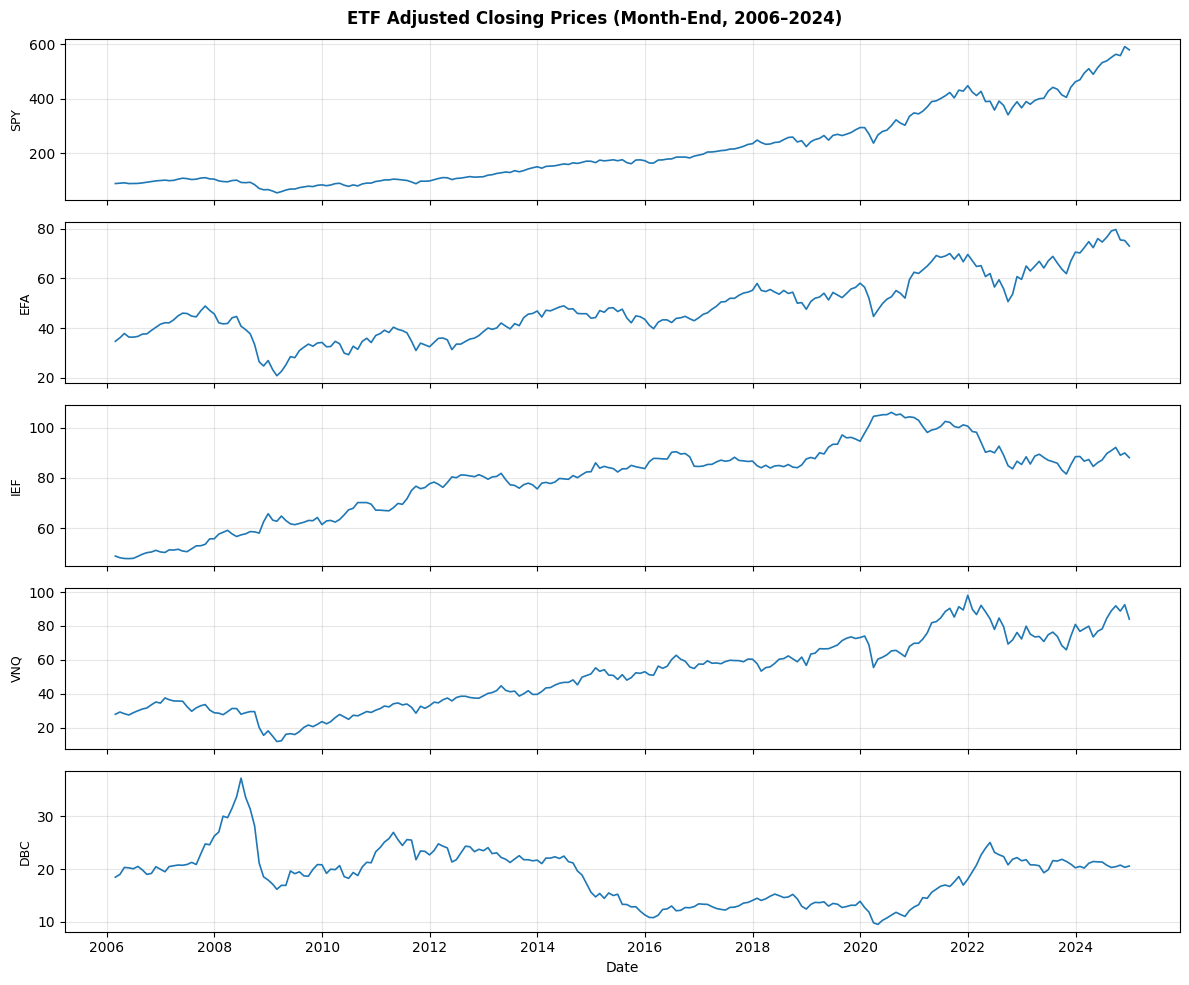

In [2]:
fig, axes = plt.subplots(len(ETFS), 1, figsize=(12, 10), sharex=True)
for ax, etf in zip(axes, ETFS):
    ax.plot(prices.index, prices[etf], linewidth=1.2)
    ax.set_ylabel(etf, fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Date")
fig.suptitle("ETF Adjusted Closing Prices (Month-End, 2006\u20132024)", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/price_charts.png", dpi=150)
plt.show()

## Plot 2: Monthly Return Distributions
Histogram of monthly returns for each ETF. The red dashed line marks the mean return.

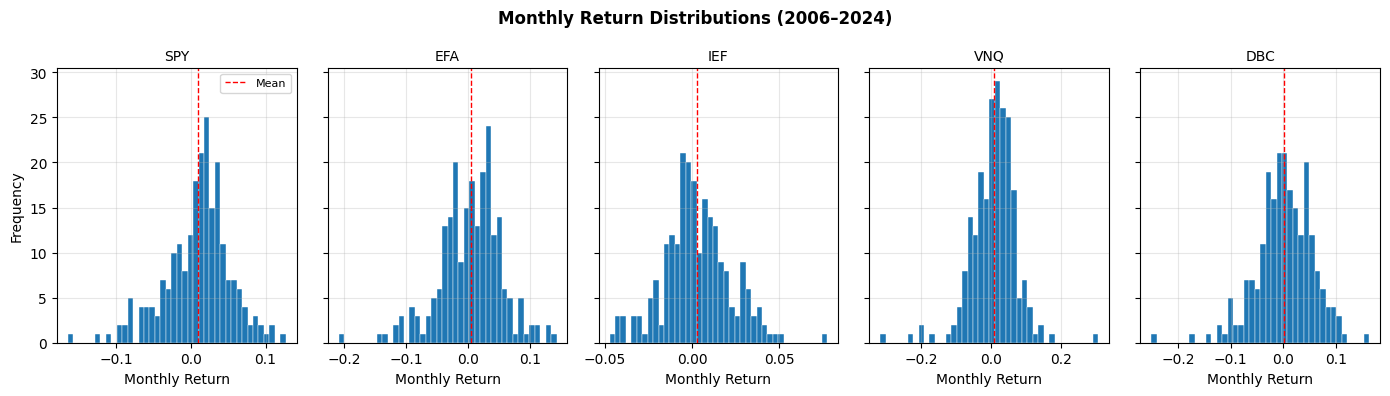

In [3]:
fig, axes = plt.subplots(1, len(ETFS), figsize=(14, 4), sharey=True)
for ax, etf in zip(axes, ETFS):
    ax.hist(returns[etf], bins=40, edgecolor="white", linewidth=0.3)
    ax.axvline(returns[etf].mean(), color="red", linestyle="--", linewidth=1, label="Mean")
    ax.set_title(etf, fontsize=10)
    ax.set_xlabel("Monthly Return")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Frequency")
axes[0].legend(fontsize=8)
fig.suptitle("Monthly Return Distributions (2006\u20132024)", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/return_distributions.png", dpi=150)
plt.show()

## Plot 3: Rolling Correlation Heatmap
Average pairwise correlation between ETFs across all rolling 12-month windows over the full period.

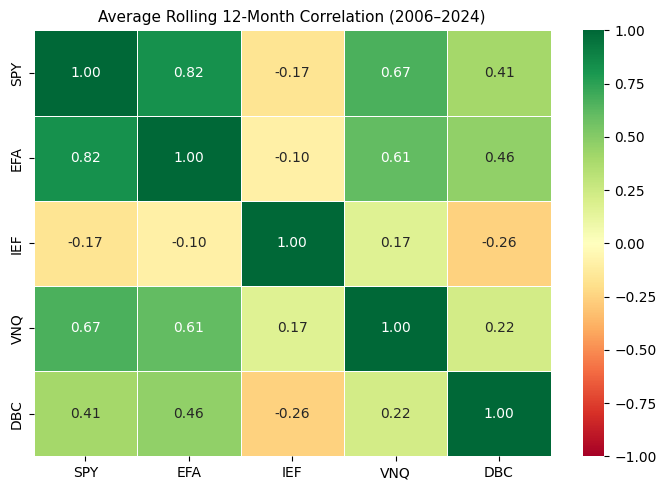

In [4]:
snapshots = []
for end_date in prices.index[12:]:
    window = returns.loc[:end_date].tail(12)
    snapshots.append(window.corr())

avg_corr = pd.concat([c.stack() for c in snapshots], axis=1).mean(axis=1).unstack()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(avg_corr, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Average Rolling 12-Month Correlation (2006\u20132024)", fontsize=11)
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/rolling_correlation_heatmap.png", dpi=150)
plt.show()